In [ ]:
import os
import requests
import zipfile
import io
from openai import OpenAI
from IPython.display import Image, display

api_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(api_key=api_key)

print("Setup Complete. API Key configured.")

print("Setup Complete. API Key configured.")

Setup Complete. API Key configured.


--- Task 1 Demo ---
Marketing Text:
Are you ready to elevate your career in the tech industry? Introducing 'Cloud Architect Pro' - the ultimate course for mastering cloud computing with Azure and AWS. 

As a tech professional, staying ahead of the curve is crucial in today's competitive landscape. With our comprehensive program, you'll gain the skills and knowledge needed to become a top cloud architect.

From designing scalable cloud solutions to optimizing performance, this course covers everything you need to know to excel in the field. Plus, with hands-on training and real-world projects, you'll have the opportunity to apply your new skills in a practical setting.

Don't miss out on this chance to take your career to the next level. Enroll in 'Cloud Architect Pro' today and join the ranks of elite cloud architects. #CloudComputing #Azure #AWS #TechProfessional #CareerDevelopment

Image saved to: marketing_Cloud_Architect_Pro.png


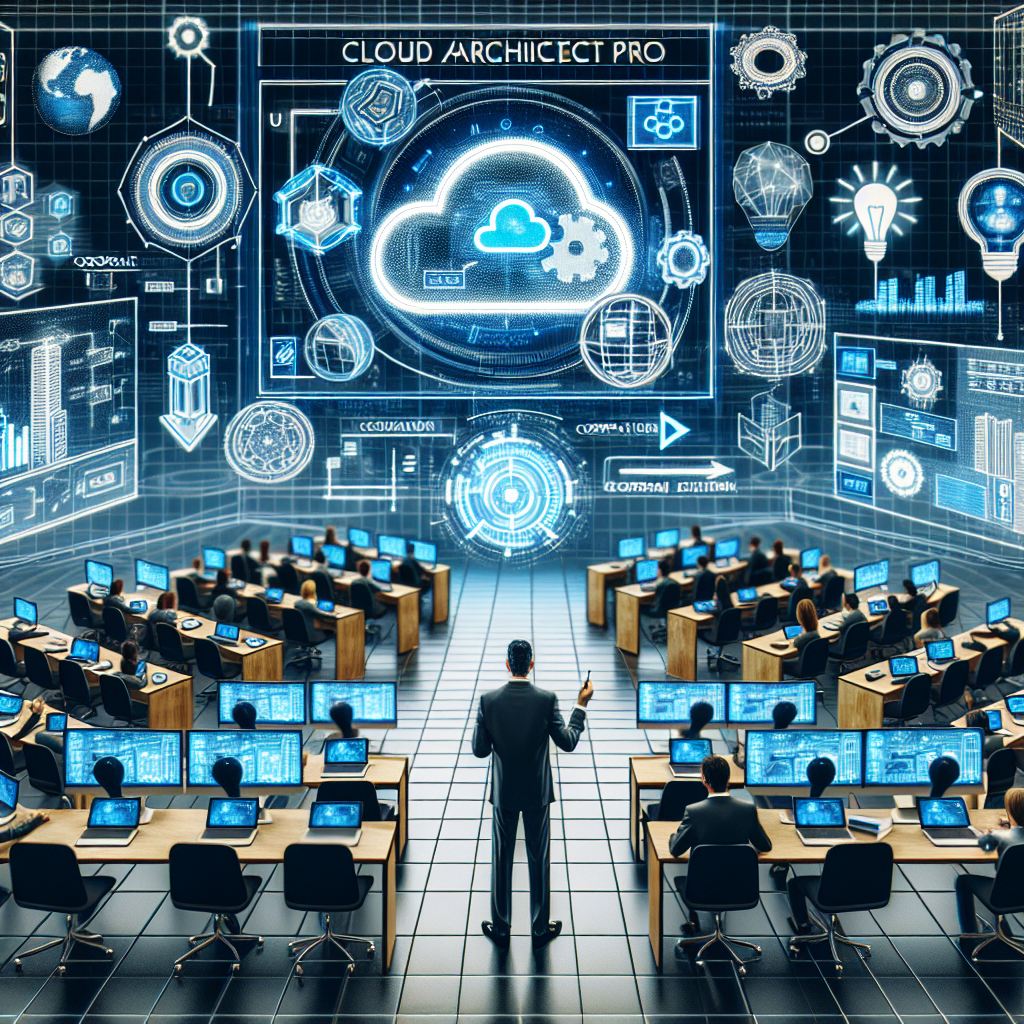

In [5]:
# Task 1: Marketing content generator for LinkedIn
def generate_marketing_content(course_name, course_description):
    """
    Generates LinkedIn marketing text and a DALL-E image for a course.
    """
    # 1. Generate Text
    prompt_text = f"Write a persuasive LinkedIn marketing post for a course named '{course_name}'. \nDescription: {course_description}\nTarget audience: Tech professionals. Tone: Professional and exciting. Include hashtags."
    
    response_text = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt_text}],
        temperature=0.7
    )
    marketing_text = response_text.choices[0].message.content
    
    # 2. Generate Image
    prompt_image = f"A professional, futuristic, and inspiring illustration for an IT course about {course_name}. High tech style, corporate education context."
    
    response_image = client.images.generate(
        model="dall-e-3",
        prompt=prompt_image,
        size="1024x1024",
        quality="standard",
        n=1,
    )
    image_url = response_image.data[0].url
    
    # Download Image
    img_data = requests.get(image_url).content
    filename = f"marketing_{course_name.replace(' ', '_')}.png"
    with open(filename, 'wb') as handler:
        handler.write(img_data)
        
    return marketing_text, filename, image_url


print("--- Task 1 Demo ---")
desc = "Master the art of cloud computing with Azure and AWS."
text, img_path, img_url = generate_marketing_content("Cloud Architect Pro", desc)
print(f"Marketing Text:\n{text}\n")
print(f"Image saved to: {img_path}")
display(Image(filename=img_path, width=300))

In [6]:
# Task 2: Catchy title generator
def generate_catchy_titles(course_description, num_titles=5):
    prompt = f"Generate {num_titles} catchy and professional course titles for the following course description: {course_description}"
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content


print("--- Task 2 Demo ---")
titles = generate_catchy_titles("A beginner course for machine learning using Python and Scikit-learn.")
print(titles)

--- Task 2 Demo ---
1. "Python for Machine Learning: Mastering Scikit-learn for Beginners"
2. "Unlocking the Power of Machine Learning with Python and Scikit-learn"
3. "Crash Course in Machine Learning: Python and Scikit-learn Essentials"
4. "Python and Scikit-learn Bootcamp: Your Gateway to Machine Learning"
5. "Foundations of Machine Learning: Learn Python and Scikit-learn from Scratch"


In [7]:
# Task 3 and 4: Detailed Course Outlines (Technical ans Non-Technical)
def generate_course_outline(topic, audience_type="technical"):
    if audience_type == "non-technical":
        prompt = f"Create a detailed course outline for a non-technical audience about '{topic}'. Focus on business value, high-level concepts, and real-world applications. Avoid jargon."
    else:
        prompt = f"Create a detailed, deep-dive technical course outline for '{topic}'. Include modules on architecture, implementation, code labs, and advanced best practices."

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Example Usage
print("--- Task 3: Technical Output ---")
tech_outline = generate_course_outline("Kubernetes Architecture")
print(tech_outline[:500] + "...\n") # Print first 500 chars

print("--- Task 4: Non-Technical Output ---")
non_tech_outline = generate_course_outline("Kubernetes Architecture", audience_type="non-technical")
print(non_tech_outline[:500] + "...")

--- Task 3: Technical Output ---
Course Title: Kubernetes Architecture Deep-Dive

Module 1: Introduction to Kubernetes
- Overview of Kubernetes
- Key concepts and terminology
- Evolution of Kubernetes architecture
- Comparison with other container orchestration platforms

Module 2: Kubernetes Architecture Overview
- Master Components
  - API Server
  - Controller Manager
  - Scheduler
  - etcd
- Node Components
  - Kubelet
  - Kube-proxy
  - Container Runtime
- Networking in Kubernetes
- Storage in Kubernetes

Module 3: Kuberne...

--- Task 4: Non-Technical Output ---
Course Title: Understanding Kubernetes Architecture for Business Applications

Course Overview:
In this course, you will learn about Kubernetes, a powerful tool for managing containerized applications. You will understand the architecture of Kubernetes, its key components, and how it can benefit your business by enabling efficient deployment, scaling, and management of applications. 

Module 1: Introduction to Kubernetes


In [8]:
# Task 5: Exercise Generator
def generate_exercises(subject):
    prompt = f"Create 5 practical exercise prompts/templates for students learning about '{subject}'. Include a mix of code tasks and design scenarios."
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# Example Usage
print("--- Task 5 Demo ---")
exercises = generate_exercises("Python Decorators")
print(exercises)

--- Task 5 Demo ---
1. Code Task: Write a decorator function in Python that prints the time taken for a given function to execute. Use the time module to calculate the execution time and print it along with the function's name. Test the decorator by applying it to a simple arithmetic operation function and observe the output.

2. Code Task: Implement a memoization decorator in Python that caches the results of a function to improve performance. Create a recursive Fibonacci function and apply the memoization decorator to it. Test the function with different input values and compare the execution time with and without memoization.

3. Design Scenario: You are building a web application that requires user authentication for certain routes. Create a decorator function in Python that checks if a user is logged in before allowing access to the route. Implement a dummy user authentication system with hardcoded credentials and use the decorator to secure a route that displays sensitive informa